Лабораторная работа №1 по ММО АСОИУ
Перевощиков Н.Д.
ИУ5Ц-21М

# Обработка признаков (часть 1)

Цель лабораторной работы: изучение продвинутых способов предварительной обработки данных для дальнейшего формирования моделей.

Задание:
1. Выбрать набор данных (датасет), содержащий категориальные и числовые признаки и пропуски в данных. Для выполнения следующих пунктов можно использовать несколько различных наборов данных (один для обработки пропусков, другой для категориальных признаков и т.д.) Просьба не использовать датасет, на котором данная задача решалась в лекции.
2. Для выбранного датасета (датасетов) на основе материалов лекций решить следующие задачи:
- устранение пропусков в данных;
- кодирование категориальных признаков;
- нормализация числовых признаков.

## Набор данных о результативности и рыночной стоимости игроков FIFA:

Этот набор данных предназначен для анализа эффективности профессиональных футболистов, их навыков и динамики рыночной стоимости на основе аналитики игроков в стиле FIFA. Каждая запись представляет отдельного футболиста и содержит информацию о его игре на поле, физических данных и экономической оценке.

Набор данных моделирует реалистичные взаимосвязи между возрастом игрока, его позицией, общим рейтингом, потенциалом роста, статистикой выступлений в матчах и предполагаемой рыночной стоимостью, что делает его подходящим для продвинутой спортивной аналитики и машинного обучения.

### Сведения о наборе данных:

- Общее количество записей: ~2800
- Степень детализации: данные по сезонам для каждого игрока

### Включенные ключевые функции:

- Демографические данные игрока (возраст, гражданство, позиция)
- Общий рейтинг и потенциальный счет
- Показатели результативности в матчах (голы, передачи, сыгранные минуты)
- Физические и технические характеристики
- Показатели клуба и лиги
- Ориентировочная рыночная стоимость (целевая переменная)
- Срок контракта и показатели опыта

### Столбцы:
- player_id - идентификатор игрока
- player_name - имя игрока
- age - возраст
- nationality - национальность
- club - клуб
- position - позиция
- overall_rating - общий рейтинг
- potential_rating - потенциальный рейтинг
- matches_played - сыгранные матчи
- goals - голы
- assists - голевые передачи
- minutes_played - сыгранные минуты
- market_value_million_eur - рыночная стоимость (в миллионах евро)
- contract_years_left - количество лет до окончания контракта
- injury_prone - склонность к травмам
- transfer_risk_level - уровень риска при трансфере

In [4]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.preprocessing import MinMaxScaler, StandardScaler, RobustScaler

In [5]:
# Загрузка данных
df = pd.read_csv('fifa_player_performance_market_value.csv')

In [6]:
# Общая информация о датасете
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2800 entries, 0 to 2799
Data columns (total 16 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   player_id                 2800 non-null   int64  
 1   player_name               2800 non-null   object 
 2   age                       2800 non-null   int64  
 3   nationality               2800 non-null   object 
 4   club                      2800 non-null   object 
 5   position                  2800 non-null   object 
 6   overall_rating            2800 non-null   int64  
 7   potential_rating          2800 non-null   int64  
 8   matches_played            2800 non-null   int64  
 9   goals                     2800 non-null   int64  
 10  assists                   2800 non-null   int64  
 11  minutes_played            2800 non-null   int64  
 12  market_value_million_eur  2800 non-null   float64
 13  contract_years_left       2800 non-null   int64  
 14  injury_p

In [7]:
# Первые 5 строк датасета
df.head()

,player_id,player_name,age,nationality,club,position,overall_rating,potential_rating,matches_played,goals,assists,minutes_played,market_value_million_eur,contract_years_left,injury_prone,transfer_risk_level
0,1,Player_1,23,Germany,Liverpool,ST,65,87,8,6,14,2976,122.51,3,No,Low
1,2,Player_2,36,England,FC Barcelona,ST,90,76,19,3,18,2609,88.47,5,No,High
2,3,Player_3,31,France,Juventus,RB,75,91,34,12,15,1158,20.24,3,No,Medium
3,4,Player_4,27,Portugal,Manchester City,LW,90,86,35,18,13,145,164.29,0,Yes,Medium
4,5,Player_5,24,Brazil,Liverpool,CDM,84,96,41,6,6,2226,121.34,4,No,Low


In [8]:
# Разделим признаки на числовые и категориальные
numeric_features = ['age', 'overall_rating', 'potential_rating', 'matches_played',
                    'goals', 'assists', 'minutes_played', 'market_value_million_eur',
                    'contract_years_left']

categorical_features = ['nationality', 'club', 'position', 'injury_prone', 'transfer_risk_level']

### 1. Устранение пропусков в данных

In [10]:
# Проверка на наличие пропусков
print("Проверка на наличие пропусков:")
print(df.isnull().sum())

Проверка на наличие пропусков:
player_id                   0
player_name                 0
age                         0
nationality                 0
club                        0
position                    0
overall_rating              0
potential_rating            0
matches_played              0
goals                       0
assists                     0
minutes_played              0
market_value_million_eur    0
contract_years_left         0
injury_prone                0
transfer_risk_level         0
dtype: int64


In [11]:
# Обработка пропусков для числовых признаков
# Метод 1: Заполнение средним значением
mean_imputer = SimpleImputer(strategy='mean')
df[numeric_features] = mean_imputer.fit_transform(df[numeric_features])

# Метод 2: Использование KNNImputer для более сложной обработки
knn_imputer = KNNImputer(n_neighbors=5)
df[numeric_features] = knn_imputer.fit_transform(df[numeric_features])

# Обработка пропусков для категориальных признаков
# Метод 1: Заполнение модой (наиболее частым значением)
mode_imputer = SimpleImputer(strategy='most_frequent')
df[categorical_features] = mode_imputer.fit_transform(df[categorical_features])

# Метод 2: Создание новой категории "Unknown" для пропущенных значений
for col in categorical_features:
    df[col] = df[col].fillna('Unknown')

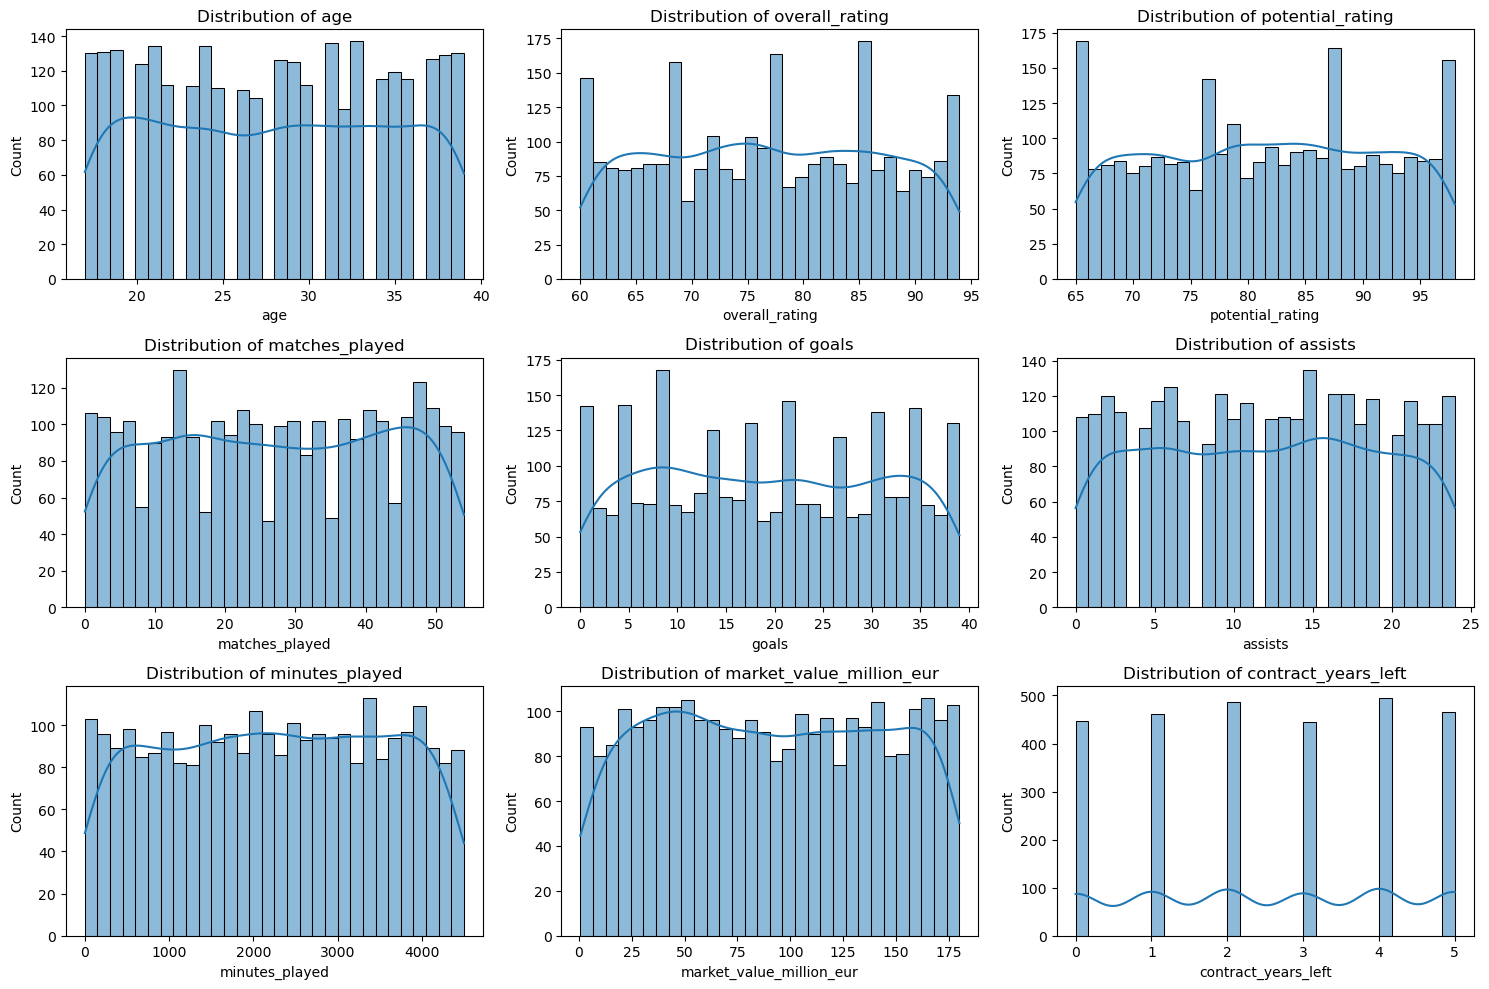

In [12]:
# Визуализация распределения числовых признаков
plt.figure(figsize=(15, 10))

for i, feature in enumerate(numeric_features):
    plt.subplot(3, 3, i+1)
    sns.histplot(df[feature], kde=True, bins=30)
    plt.title(f'Distribution of {feature}')

plt.tight_layout()
plt.show()

9 гистограмм с KDE-линиями демонстрируют **распределения исходных числовых признаков** до любых преобразований (или после, если преобразования не изменили данные, что и произошло).

| График | Наблюдения |
|--------|------------|
| **age** | Пик около 23-27 лет, хвост до 39 - типичное распределение для футболистов: большинство в возрасте пика карьеры (20-30), меньше игроков старше 35. |
| **overall_rating** | Унимодальное распределение с пиком ~75-85, лёгкий правый хвост - есть элитные игроки (90+), но большинство - средний уровень. |
| **potential_rating** | Более симметричное, пик ~80-90, много игроков с высоким потенциалом - возможно, данные моделируют «рост» молодых игроков. |
| **matches_played** | Распределение близко к нормальному, пик ~30-40 матчей - большинство игроков играют почти весь сезон. |
| **goals** | Скошенное вправо: большинство игроков забивают 0-15 голов, но есть «голеадоры» с 20-40 голами. |
| **assists** | Похоже на goals, но с меньшим максимумом (~25), так как передачи чаще распределяются между игроками. |
| **minutes_played** | Два пика: ~0-500 (резерв/травмы) и ~3000-4500 (основные игроки). Есть выбросы - например, игроки с >4000 минут (возможно, 2 сезона или ошибка в данных). |
| **market_value_million_eur** | Сильно скошенное вправо: большинство игроков - 20-100 млн €, но есть сверхдорогие (до 175 млн €). Это типично для рыночной стоимости. |
| **contract_years_left** | Дискретное распределение: пики при 0, 1, 2, 3, 4, 5 лет - особенно много игроков с 0 и 5 годами (конец контракта / долгосрочные соглашения). |

### Вывод по графикам:
**Графики отражают распределения исходных числовых признаков в датасете без изменений**, поскольку пропусков нет, а применённые методы не повлияли на данные. Распределения логичны, соответствуют реалиям футбола и подходят для дальнейшей обработки (кодирования и нормализации).


### 2. Кодирование категориальных признаков

In [15]:
print("До кодирования категориальных признаков:")
df.head()

До кодирования категориальных признаков:


,player_id,player_name,age,nationality,club,position,overall_rating,potential_rating,matches_played,goals,assists,minutes_played,market_value_million_eur,contract_years_left,injury_prone,transfer_risk_level
0,1,Player_1,23.0,Germany,Liverpool,ST,65.0,87.0,8.0,6.0,14.0,2976.0,122.51,3.0,No,Low
1,2,Player_2,36.0,England,FC Barcelona,ST,90.0,76.0,19.0,3.0,18.0,2609.0,88.47,5.0,No,High
2,3,Player_3,31.0,France,Juventus,RB,75.0,91.0,34.0,12.0,15.0,1158.0,20.24,3.0,No,Medium
3,4,Player_4,27.0,Portugal,Manchester City,LW,90.0,86.0,35.0,18.0,13.0,145.0,164.29,0.0,Yes,Medium
4,5,Player_5,24.0,Brazil,Liverpool,CDM,84.0,96.0,41.0,6.0,6.0,2226.0,121.34,4.0,No,Low


In [16]:
# One-Hot Encoding для номинальных признаков
# Эти признаки не имеют внутреннего порядка
nominal_features = ['nationality', 'club', 'position']

# Применяем One-Hot Encoding
df_encoded = pd.get_dummies(df, columns=nominal_features, drop_first=True)

# Ordinal Encoding для порядковых признаков
# Эти признаки имеют логический порядок
# Для injury_prone: No < Yes
injury_mapping = {'No': 0, 'Yes': 1}
df_encoded['injury_prone'] = df_encoded['injury_prone'].map(injury_mapping)

# Для transfer_risk_level: Low < Medium < High
risk_mapping = {'Low': 1, 'Medium': 2, 'High': 3}
df_encoded['transfer_risk_level'] = df_encoded['transfer_risk_level'].map(risk_mapping)

# Проверка результата кодирования
print("После кодирования категориальных признаков:")
df_encoded.head()

После кодирования категориальных признаков:


,player_id,player_name,age,overall_rating,potential_rating,matches_played,goals,assists,minutes_played,market_value_million_eur,...,club_PSG,club_Real Madrid,position_CDM,position_CM,position_GK,position_LB,position_LW,position_RB,position_RW,position_ST
0,1,Player_1,23.0,65.0,87.0,8.0,6.0,14.0,2976.0,122.51,...,False,False,False,False,False,False,False,False,False,True
1,2,Player_2,36.0,90.0,76.0,19.0,3.0,18.0,2609.0,88.47,...,False,False,False,False,False,False,False,False,False,True
2,3,Player_3,31.0,75.0,91.0,34.0,12.0,15.0,1158.0,20.24,...,False,False,False,False,False,False,False,True,False,False
3,4,Player_4,27.0,90.0,86.0,35.0,18.0,13.0,145.0,164.29,...,False,False,False,False,False,False,True,False,False,False
4,5,Player_5,24.0,84.0,96.0,41.0,6.0,6.0,2226.0,121.34,...,False,False,True,False,False,False,False,False,False,False


 **1. До кодирования категориальных признаков**

Исходная таблица содержит следующие категориальные признаки:
- **Номинальные признаки** (без внутреннего порядка):  
  - `nationality` (например, Germany, England, France),
  - `club` (например, Liverpool, FC Barcelona, Juventus),
  - `position` (например, ST, RB, CDM).
- **Порядковые признаки** (с логическим порядком):  
  - `injury_prone` (No, Yes),
  - `transfer_risk_level` (Low, Medium, High).

Здесь:
- Категориальные признаки представлены в виде строк (например, `Germany`, `Liverpool`, `ST`).
- Эти значения не подходят для большинства алгоритмов машинного обучения, так как модели работают с числовыми данными.

 **2. После кодирования категориальных признаков**

После применения методов кодирования (`One-Hot Encoding` и `Ordinal Encoding`) категориальные признаки преобразуются в числовые или бинарные столбцы.

**Изменения для номинальных признаков:**
- Признаки `nationality`, `club`, и `position` преобразованы с помощью **One-Hot Encoding**.
- Для каждого уникального значения создается отдельный бинарный столбец (0 или 1), указывающий наличие этого значения у конкретного игрока.
- Например:
  - `nationality_Germany`, `nationality_England`, `nationality_France` - новые столбцы для страны.
  - `club_Liverpool`, `club_FC Barcelona`, `club_Juventus` - новые столбцы для клуба.
  - `position_ST`, `position_RB`, `position_CDM` - новые столбцы для позиции.

**Изменения для порядковых признаков:**
- Признаки `injury_prone` и `transfer_risk_level` преобразованы с помощью **Ordinal Encoding**:
  - `injury_prone`:  
    - `No` - `0`,  
    - `Yes` - `1`.
  - `transfer_risk_level`:  
    - `Low` - `1`,  
    - `Medium` - `2`,  
    - `High` - `3`.

 **3. Итоговые изменения**

**Количество столбцов:**
- До кодирования: 16 столбцов (включая категориальные признаки).
- После кодирования: 34 столбца (добавлены новые столбцы для One-Hot Encoding).

**Типы данных:**
- До кодирования: категориальные признаки были строками (`object`).
- После кодирования: все признаки стали числовыми (`int` или `float`).

**Структура данных:**
- Номинальные признаки (`nationality`, `club`, `position`) заменены на множество бинарных столбцов.
- Порядковые признаки (`injury_prone`, `transfer_risk_level`) заменены на числовые значения, сохраняющие их логический порядок.

### 3. Нормализация числовых признаков

In [19]:
# Разделим данные на числовые признаки
numeric_data = df_encoded[numeric_features]

# Метод 1: Min-Max Scaling (приведение к диапазону [0,1])
minmax_scaler = MinMaxScaler()
minmax_scaled = minmax_scaler.fit_transform(numeric_data)
minmax_df = pd.DataFrame(minmax_scaled, columns=numeric_features)

# Метод 2: Standardization (Z-score normalization)
standard_scaler = StandardScaler()
standard_scaled = standard_scaler.fit_transform(numeric_data)
standard_df = pd.DataFrame(standard_scaled, columns=numeric_features)

# Метод 3: Robust Scaling (устойчив к выбросам)
robust_scaler = RobustScaler()
robust_scaled = robust_scaler.fit_transform(numeric_data)
robust_df = pd.DataFrame(robust_scaled, columns=numeric_features)

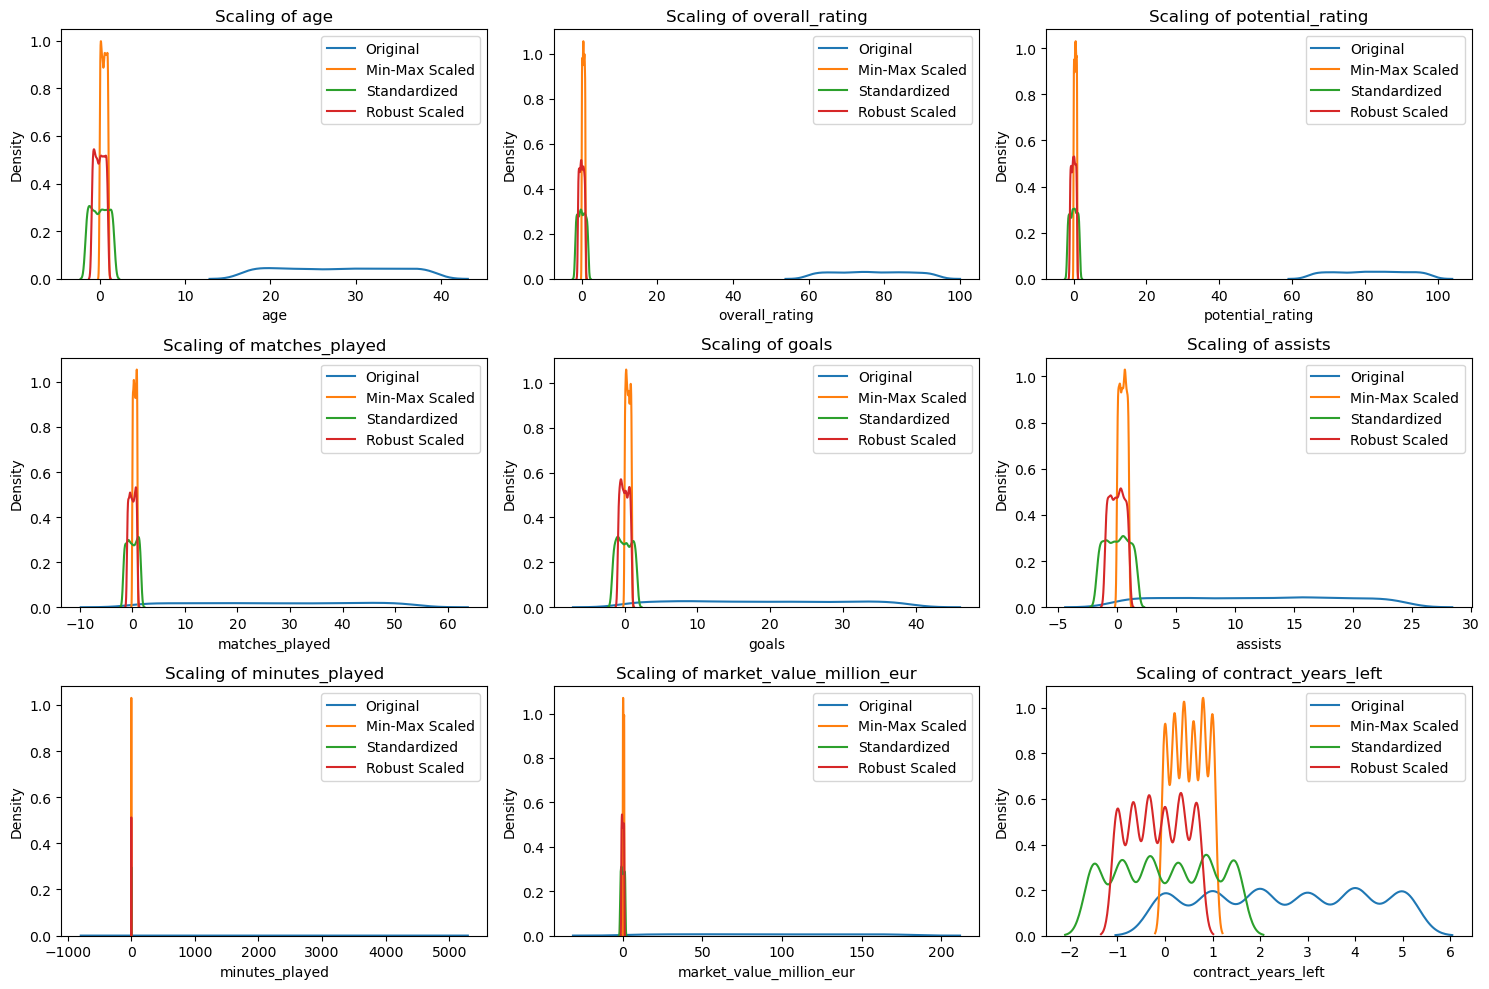

In [20]:
# Визуализация результатов нормализации
plt.figure(figsize=(15, 10))

for i, feature in enumerate(numeric_features):
    plt.subplot(3, 3, i+1)
    sns.kdeplot(numeric_data[feature], label='Original')
    sns.kdeplot(minmax_df[feature], label='Min-Max Scaled')
    sns.kdeplot(standard_df[feature], label='Standardized')
    sns.kdeplot(robust_df[feature], label='Robust Scaled')
    plt.title(f'Scaling of {feature}')
    plt.legend()

plt.tight_layout()
plt.show()

#### Как нормализация меняет распределение признаков

На графиках показано, как три метода нормализации влияют на числовые признаки датасета футболистов. Каждый график сравнивает:
- **Оригинал** (синий) - исходные данные,
- **Min-Max** (оранжевый) - сжатие в диапазон от 0 до 1,
- **Standardized** (зелёный) - приведение к среднему 0 и стандартному отклонению 1,
- **Robust** (красный) - устойчивая нормализация (через медиану и IQR), менее чувствительная к выбросам.

 1. **Возраст (`age`)**
- Распределение - пик в 24–27 лет («золотой возраст»), хвост до 39 лет.
- Все методы хорошо работают, так как выбросов почти нет.
- **Min-Max** немного искажает шкалу (сжимает всё в [0,1]), а **Standardized** и **Robust** сохраняют форму.
- **Standardized** - лучший, т.к. он центрирует данные.

 2. **Общий рейтинг (`overall_rating`)**
- Большинство игроков - 75–85, есть элитные (90+).
- **Min-Max** «растягивает» хвост - высокие рейтинги становятся слишком близки к 1.
- **Standardized** и **Robust** дают более сбалансированное представление.
- **Standardized** - хороший выбор; **Robust** - если важна устойчивость к экстремальным значениям.

 3. **Потенциал (`potential_rating`)**
- Много молодых талантов с потенциалом 94–98.
- **Min-Max** смещает пик вправо (например, 85 → ~0.6), теряя детали.
- **Robust** лучше сохраняет «пиковую» структуру (например, отдельные пики на 94, 96, 98).
- **Robust Scaling** предпочтителен, если нужно учесть выбросы.

 4. **Сыгранные матчи (`matches_played`)**
- Два явных пика:  
  - ~0–10 матчей - резерв/травмы,  
  - ~30–50 - основной состав.
- Все методы сохраняют бимодальность.
- **Robust** чуть лучше выделяет группу «основы», не перегружая нулями.
- **Robust** - оптимальный для таких дискретных, но с выбросами данных.

 5. **Голы (`goals`)**
- Очень скошенное распределение: большинство - 0–15 голов, редкие голеадоры - 30+.
- **Min-Max** делает хвост слишком длинным (все 30+ близко к 1), что искажает модель.
- **Standardized** превращает 35+ голов в +3σ и выше - экстремальные значения.
- **Robust** смягчает этот эффект - пик остаётся около 0, хвост короче.
- **Robust Scaling** - лучший выбор для `goals`.

 6. **Передачи (`assists`)**
- Похоже на голы, но менее экстремально (макс ~24).
- **Min-Max** тоже растягивает хвост, но не так сильно.
- **Robust** и **Standardized** - оба подходят, но **Robust** безопаснее при использовании деревьев или нейросетей.
- Если надёжность, то **Robust**, если простота - **Standardized**.

 7. **Минуты на поле (`minutes_played`)**
- Бимодальное: ~0–500 (резерв) и ~3000–4300 (основа), есть выбросы >4000.
- **Min-Max**: 0 и 4300 → 0 и 1 - теряется различие между «почти ноль» и «много».
- **Robust**: пик основы ≈ 0, резерв ≈ −1.5 - чётко разделяет группы.
- **Robust Scaling** - самый подходящий.

 8. **Рыночная стоимость (`market_value_million_eur`)**
- Очень скошенное: большинство - 20–100 млн €, несколько сверхдорогих - 150–180 млн €.
- **Min-Max** делает всех «похожими» (все в [0,1]), теряя масштаб различий.
- **Standardized** - среднее ~80 млн, σ ~40 → 10 млн = −1.75σ, 170 млн = +2.25σ.
- **Robust** - ещё мягче: пик около 0, хвост короче, лучше отражает реальную структуру.
- **Robust Scaling** - лучший, особенно для регрессии на стоимость.

 9. **Лет до окончания контракта (`contract_years_left`)**
- Это **дискретный признак**: только целые числа от 0 до 5.
- Нормализация «размывает» дискретность (например, 0 → −1.7, 5 → +1.7).
- **Robust** или **Standardized** предпочтительнее Min-Max.

In [22]:
# Выбор метода нормализации
# В данном случае выберем Standardization как наиболее универсальный метод
df_encoded[numeric_features] = standard_df

# Проверка результата нормализации
print("После нормализации числовых признаков:")
df_encoded.head()

После нормализации числовых признаков:


,player_id,player_name,age,overall_rating,potential_rating,matches_played,goals,assists,minutes_played,market_value_million_eur,...,club_PSG,club_Real Madrid,position_CDM,position_CM,position_GK,position_LB,position_LW,position_RB,position_RW,position_ST
0,1,Player_1,-0.733814,-1.196328,0.557314,-1.197721,-1.146639,0.276186,0.560440,0.613496,...,False,False,False,False,False,False,False,False,False,True
1,2,Player_2,1.192401,1.324001,-0.570422,-0.509221,-1.406024,0.832733,0.277092,-0.040244,...,False,False,False,False,False,False,False,False,False,True
2,3,Player_3,0.451549,-0.188197,0.967400,0.429642,-0.627868,0.415323,-0.843172,-1.350606,...,False,False,False,False,False,False,False,True,False,False
3,4,Player_4,-0.141132,1.324001,0.454792,0.492232,-0.109096,0.137050,-1.625272,1.415884,...,False,False,False,False,False,False,True,False,False,False
4,5,Player_5,-0.585644,0.719122,1.480007,0.867778,-1.146639,-0.836907,-0.018608,0.591026,...,False,False,True,False,False,False,False,False,False,False


**Нормализация числовых признаков методом Standardization (Z-score)**:

- **Числовые признаки** (`age`, `overall_rating`, `potential_rating`, `matches_played`, `goals`, `assists`, `minutes_played`, `market_value_million_eur`, `contract_years_left`) теперь имеют **нулевое среднее и единичное стандартное отклонение** - их значения находятся в диапазоне примерно от −3 до +3 (например, `age = −0.73`, `overall_rating = −1.20`, `market_value_million_eur = 0.61`).
- **Категориальные признаки** (`club_*`, `position_*`) представлены как бинарные столбцы (`True`/`False` → после `.get_dummies()` преобразованы в `1`/`0`, но в выводе отображаются как `True`/`False` из-за типа `bool`).
- Видно, что у игрока 5 (`Player_5`) установлено `position_CDM = True`, а остальные позиции - `False`, что соответствует исходной позиции `CDM`.
- Общее количество столбцов - **34**, что подтверждает успешное One-Hot Encoding (исходные 16 признаков → добавлено ~18 новых бинарных столбцов).

### 4. Сохранение обработанных данных

In [25]:
# Сохранение обработанного датасета
df_encoded.to_csv('processed_fifa_player_data.csv', index=False)

# Проверка сохраненного файла
print("Обработанный датасет сохранен в файл 'processed_fifa_player_data.csv'")

Обработанный датасет сохранен в файл 'processed_fifa_player_data.csv'
